# Employment in the United States (2021 – Present)

## Monthly Labor Market Analysis

## Description

This notebook provides a technical analysis of U.S. labor market dynamics using monthly nonfarm payroll data from the Federal Reserve Economic Data (FRED).

The analysis focuses on:

- Monthly changes in total nonfarm payrolls and foundational labor force metrics
- Moving averages and rolling baseline trendlines since 2016
- Structural shifts in employment behavior following recent systemic events

This notebook examines 'granular monthly variability' to identify transitions between:

- Stable expansion periods  
- Post-Covid recovery normalization  
- Late-cycle slowdown in 2024 
- Near-zero growth with increased volatility after 2024

Special attention is given from `2024 onward`, where labor market behavior transitioned into variance-dominated movement.

---

## Objectives

- Analyze U.S. payroll growth and core labor metrics from 2016 to present  
- Compare pre-COVID baseline conditions (2016–2019) with post-recovery behaviors (2021–present)  
- Identify the transition from steady growth to late-cycle labor market friction
- Detect regime shifts characterized by declining mean participation, widening demographic disparities, and increasing duration volatility  
- Contextualize employment behavior and labor supply drops around critical political, tariff, and judicial milestones  
- Provide a time-sensitive interpretation of labor market stability, latent economic slack, and ongoing structural risk

---

## Data Source & Core Matrices

- **Federal Reserve Economic Data (FRED)**

### 1. Key Performance Indicators (KPI Matrix)
* `PAYEMS:` Total Nonfarm Payroll Employment
* `CIVPART:` Labor Force Participation Rate
* `EMRATIO:` Employment-to-Population Ratio
* `UEMPLT5:` Unemployed Less than 5 Weeks
* `UEMP27OV:` Unemployed Longer than 27 Weeks
* `NILFWJN:` Not in Labor Force, Wants a Job

### 2. Demographic Slices (DEMO Matrix)
* `LNS14000003:` White Unemployment Rate
* `LNS14000006:` Black or African American Unemployment Rate
* `LNS14032183:` Asian Unemployment Rate
* `LNS14000009:` Hispanic or Latino Unemployment Rate
* `LNS14000001:` Adult Men Unemployment Rate
* `LNS14000002:` Adult Women Unemployment Rate
* `LNS14024887:` 16-24 Yrs. Unemployment Rate
* `LNS14000012:` 16-19 Yrs. Unemployment Rate

### Derived Analytics:
* **Monthly Job Growth:** First difference ($\Delta$) of PAYEMS  
* **3-Month Moving Average:** Rolling mean of monthly job growth  
* **12-Month Moving Average:** Trendline smoothing for the Employment-to-Population baseline  
* **Cross-Sectional Snapshots:** Single-month demographic disparity slicing  

All data streams are seasonally adjusted and reported in thousands of persons or raw percentages where applicable.

In [10]:
# Install system dependencies
!pip install pandas-datareader

In [11]:
!pip3 install --upgrade pip

In [12]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas_datareader.data as web
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

In [13]:
start = datetime(2021, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

In [14]:
# Data source
df = web.DataReader("PAYEMS", "fred", start, end)

# Metrics
df["job_growth"] = df["PAYEMS"].diff()
df["ma_3"] = df["job_growth"].rolling(3).mean()



## Post-Covid Employment Dynamics (2021–Present)

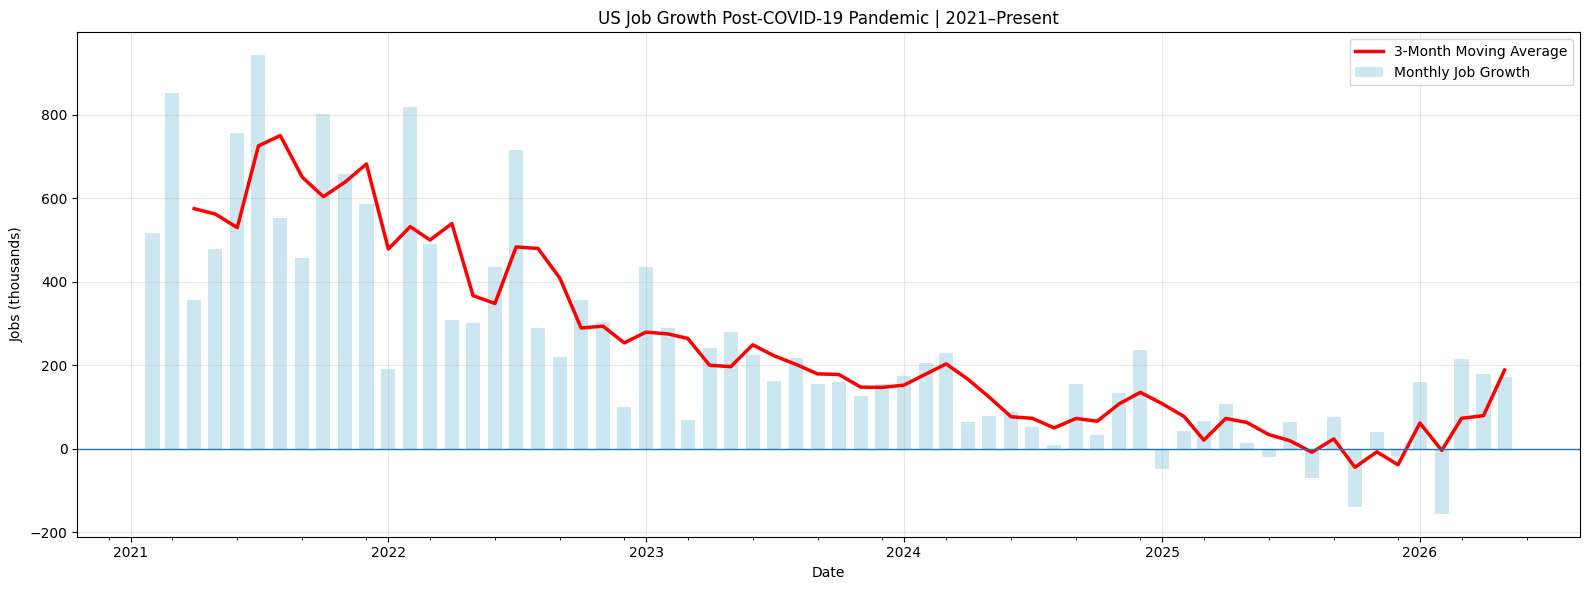

In [15]:
# 2021–Present | Post-COVID Recovery 
df_post = df[df.index >= "2021-01-01"]

plt.figure(figsize=(16, 6))

plt.bar(df_post.index, df_post["job_growth"], color = "lightblue", width = 20, alpha = 0.6, label = "Monthly Job Growth")
plt.plot(df_post.index, df_post["ma_3"], color = "red", linewidth = 2.5, label = "3-Month Moving Average")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval = 3))

plt.axhline(0, linewidth=1)
plt.grid(alpha=0.3)

plt.title("US Job Growth Post-COVID-19 Pandemic | 2021–Present")
plt.ylabel("Jobs (thousands)")
plt.xlabel("Date")
plt.legend()

plt.tight_layout()
plt.show()

## Late-Cycle Pandemic Recovery Behavior (2024–Present)

NameError: name 'evt_20feb2026' is not defined

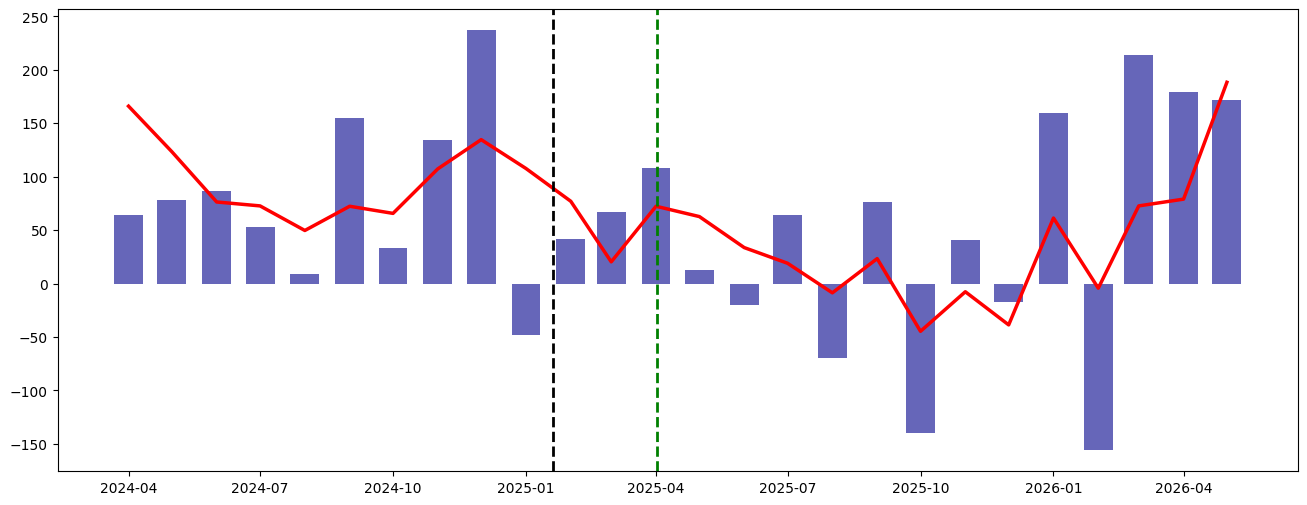

In [16]:
# Apr 2024 - Present : [Key dates:] 1/20/2025, 4/2/2025
df_focus = df[df.index >= "2024-04-01"]

plt.figure(figsize=(16, 6))

plt.bar(
    df_focus.index,
    df_focus["job_growth"],
    color="darkblue",
    width=20,
    alpha=0.6,
    label="Monthly Job Growth"
)

plt.plot(
    df_focus.index,
    df_focus["ma_3"],   
    color="red",
    linewidth=2.5,
    label="3-Month Moving Average"
)

# Key event markers
evt_20jan2025 = pd.to_datetime("2025-01-20")
evt_4apr2025 = pd.to_datetime("2025-04-02")
evt_20apr2026 = pd.to_datetime("2026-02-20")

plt.axvline(evt_20jan2025, color="black", linestyle="--", linewidth=2, label="Jan 20 Inauguration Day")
plt.axvline(evt_4apr2025, color="green", linestyle="--", linewidth=2, label="Apr 20 Liberation Day")
plt.axvline(evt_20feb2026, color="red", linestyle="--", linewidth=2, label="Feb 2026 IEEPA Decision")

# Labelss
y_max = df_focus["job_growth"].max()

plt.text(evt_20jan2025, y_max * 0.9, "2025 Inauguration", rotation=90, va='top', ha='right')
plt.text(evt_4apr2025, y_max * 0.9, "2025 Tariffs", rotation=90, va='top', ha='right')
plt.text(evt_20feb2026, y_max * 0.9, "2026 SCOTUS Decision", rotation=90, va='top', ha='right')

# Formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.axhline(0, linewidth=1)
plt.ylim(-200, 250)

plt.grid(alpha=0.3)

plt.title("US Job Growth w/ Event Markers | April 2024–Present")

plt.ylabel("Jobs (thousands)")
plt.xlabel("Date")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Advanced Metrics


### 1. Mathematical Framework & Derivative Indicators
To fully capture the late-cycle regime volatility and labor hoarding dynamics, our analysis tracks the interaction of three vital structural ratios:

* **Labor Force Participation Rate ($\text{LFPR}$):** Measures the active supply engine of the economy.
    $$\text{LFPR} = \left( \frac{\text{Labor Force}}{\text{Civilian Noninstitutional Population}} \right) \times 100$$
* **Employment-to-Population Ratio ($\text{EPOP}$):** Tracks the direct utilization rate of human capital. Unlike the headline unemployment rate ($U3$), $\text{EPOP}$ is isolated from arbitrary drops in participation, making it a cleaner proxy for structural labor demand.
    $$\text{EPOP} = \left( \frac{\text{Employed}}{\text{Civilian Noninstitutional Population}} \right) \times 100$$
* **Participation-to-Employment Gap ($\Delta_{PE}$):** Monitors divergence trends between active seekers and corporate absorption.

---

### 2. Analytical Focus Areas

#### A. Structural vs. Frictional Duration Splits
By segmenting the unemployed population by the duration of their joblessness, we isolate the underlying behavior of corporate hiring pipelines:
* **Frictional Liquidity ($<5$ Weeks):** Represents natural labor market churn, seasonal transitions, and frontline workforce re-allocations. Spikes here reflect a sudden surge in corporate separations/layoffs.
* **Structural Stagnation ($\ge 27$ Weeks):** Captures matching inefficiencies, persistent skill mismatches, and automated filtering out of long-term job seekers. When this metric rises alongside stable or falling short-term unemployment, it points to localized hiring freezes or systemic economic scarring.

#### B. Latent Labor Capacity (Marginally Attached Pool)
The data stream **"Not in Labor Force, Wants a Job Now" (`NILFWJN`)** acts as a crucial macroeconomic safety valve. 
* During periods of extreme regime volatility, traditional models fail to capture workers who drop out of active tracking metrics but remain ready to return.
* Monitoring this pool prevents underestimating the true level of economic slack when the headline participation rate declines unexpectedly.

---

### 3. Cross-Sectional Demographic Disparity
Labor market stress rarely hits evenly. By pulling granular, cross-sectional demographic matrix profiles, this analysis evaluates:
1.  **Generational Vulnerabilities:** Comparing entry-level cohorts (`16-19 Yrs.` and `16-24 Yrs.`) against prime-age workers to detect real-time adjustments in entry-level hiring sentiment.
2.  **Socioeconomic and Gender Asymmetries:** Tracking structural divergence paths across `White`, `Black or African American`, `Asian`, and `Hispanic` layers to pinpoint where macroeconomic policy shocks fall hardest during volatile periods.

In [ ]:
start = datetime(2025, 1, 1)
end = datetime.now()

kpi_series = {
    'CIVPART': 'Labor Force Participation Rate',
    'EMRATIO': 'Employment-to-Population Ratio',
    'UEMPLT5': 'Unemployed Less than 5 Weeks',
    'UEMP27OV': 'Unemployed Longer than 27 Weeks',
    'NILFWJN': 'Not in Labor Force, Wants a Job'
}

demo_series = {
    'LNS14000003': 'White',
    'LNS14000006': 'Black or African American',
    'LNS14032183': 'Asian',
    'LNS14000009': 'Hispanic or Latino',
    'LNS14000001': 'Adult Men',
    'LNS14000002': 'Adult Women',
    'LNS14024887': '16-24 Yrs.',
    'LNS14000012': '16-19 Yrs.'
}

df_kpi = web.DataReader(list(kpi_series.keys()), 'fred', start, end)
df_kpi.rename(columns = kpi_series, inplace = True)

df_demo = web.DataReader(list(kpi_series.keys()), 'fred', start, end)
df_demo.rename(columns = demo_series, inplace = True)

## Metric 1: Labor Force Participation Rate (CIVPART)


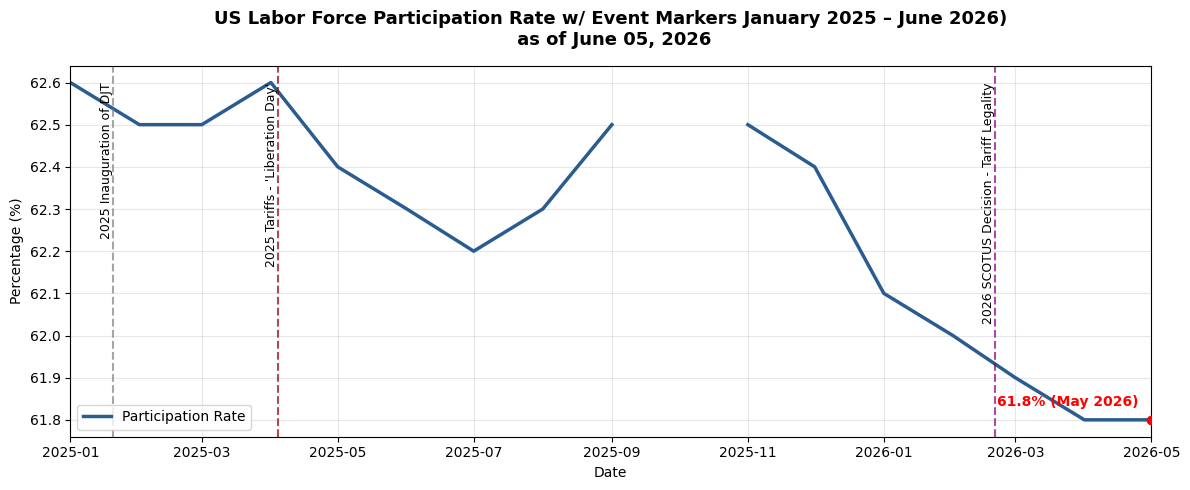

In [ ]:

plt.figure(figsize=(12, 5))
plt.plot(df_kpi.index, df_kpi['Labor Force Participation Rate'], color='#2b5c8f', linewidth=2.5, label='Participation Rate')

evt_20jan2025 = datetime(2025, 1, 20)
evt_20feb2026 = datetime(2026, 2, 20)
evt_4apr2025 = datetime(2025, 4, 4)

y_max = df_kpi['Labor Force Participation Rate'].max()

plt.axvline(evt_20jan2025, color = 'gray', linestyle = '--', alpha = 0.7)
plt.text(evt_20jan2025, y_max, "2025 Inauguration of DJT", rotation = 90, va = 'top', ha = 'right', fontsize = 9)

plt.axvline(evt_4apr2025, color = 'darkred', linestyle = '--', alpha = 0.7)
plt.text(evt_4apr2025, y_max, "2025 Tariffs - 'Liberation Day'", rotation = 90, va = 'top', ha = 'right', fontsize = 9)

plt.axvline(evt_20feb2026, color = 'purple', linestyle = '--', alpha = 0.7)
plt.text(evt_20feb2026, y_max, "2026 SCOTUS Decision - Tariff Legality", rotation = 90, va = 'top', ha = 'right', fontsize = 9)

# 5. Graph formatting parameters
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlim(datetime(2025, 1, 1), df_kpi.index.max())

plt.title(f'US Labor Force Participation Rate w/ Event Markers {start.strftime("%B %Y")} – {end.strftime("%B %Y")})\n as of {str_current_date}', fontsize=13, pad=15, weight='bold')
plt.ylabel("Percentage (%)")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.legend(loc='lower left')

latest_date = df['Labor Force Participation Rate'].dropna().index[-1]
latest_val = df['Labor Force Participation Rate'].dropna().iloc[-1]
plt.scatter(latest_date, latest_val, color = 'red', zorder = 5)
plt.annotate(f"{latest_val:.1f}% ({latest_date.strftime('%b %Y')})", 
             (latest_date, latest_val), textcoords = "offset points", 
             xytext = (-60,10), ha = 'center', weight = 'bold', color = 'red')

plt.tight_layout()
plt.show()



## Metric 2: Employment-to-Population Ratio (EMRATIO)
### Trailing 24-Month Labor Utilization vs. 12-Month Moving Average Trend

/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_40389/2374369699.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation = 45, ha = 'right')


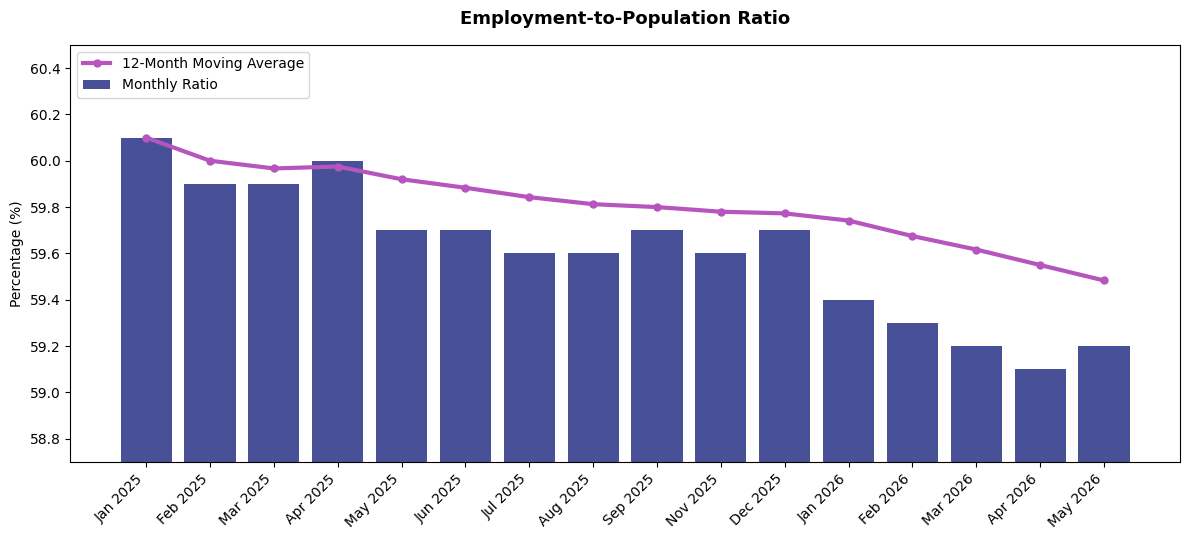

In [ ]:
df_ratio = df_kpi[['Employment-to-Population Ratio']].dropna().tail(24).copy()

df_ratio['12M_MA'] = df_ratio['Employment-to-Population Ratio'].rolling(window = 12, min_periods = 1).mean()

fig, ax = plt.subplots(figsize = (12, 5.5))
x_labels = df_ratio.index.strftime('%b %Y')

sns.barplot(
    x = x_labels, 
    y = df_ratio['Employment-to-Population Ratio'], 
    ax = ax, 
    color = "#09198E", 
    alpha = 0.8, 
    label = 'Monthly Ratio'
)

ax.plot(
    range(len(df_ratio)), 
    df_ratio['12M_MA'], 
    color = "#b655bd", 
    linewidth = 3, 
    marker = 'o', 
    markersize = 5, 
    label = '12-Month Moving Average'
)

plt.title("Employment-to-Population Ratio", fontsize = 13, pad = 15, weight = 'bold')
ax.set_xticklabels(x_labels, rotation = 45, ha = 'right')
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("")

y_min = df_ratio['Employment-to-Population Ratio'].min()
y_max = df_ratio['Employment-to-Population Ratio'].max()
ax.set_ylim(y_min - 0.4, y_max + 0.4)

ax.legend(loc = 'upper left', frameon = True)
plt.tight_layout()
plt.show()

## Metric 3: Unemployment Duration Dynamics (UEMPLT5 vs. UEMP27OV)
### Frictional Market Dynamics and Long-Term Structural Stagnation

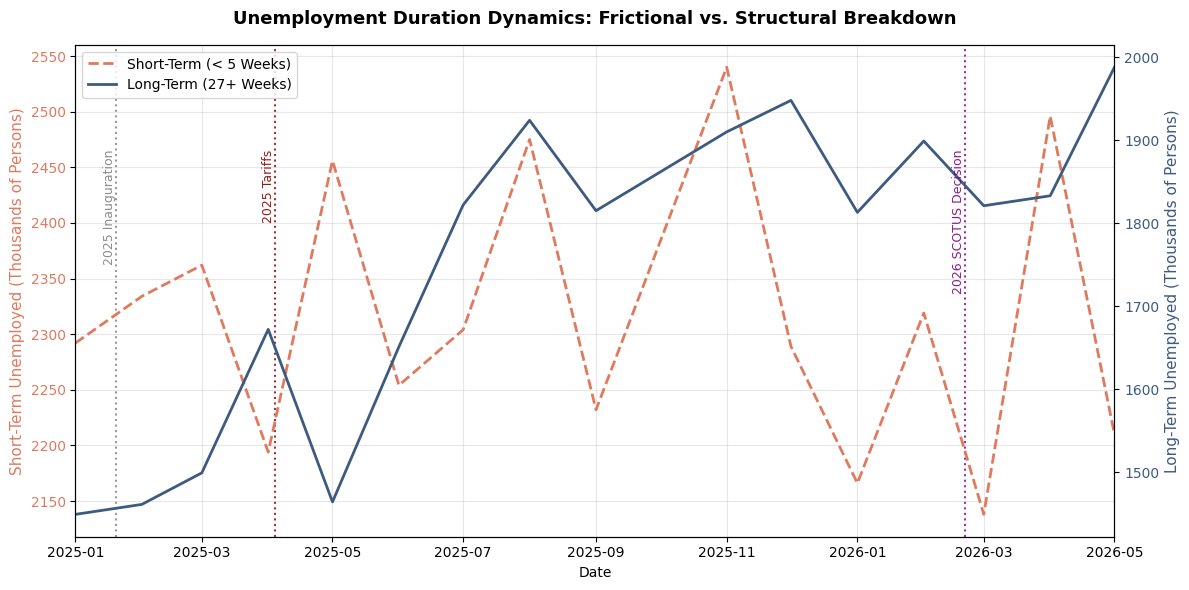

In [ ]:
df_duration = df_kpi[['Unemployed Less than 5 Weeks', 'Unemployed Longer than 27 Weeks']].dropna()

fig, ax1 = plt.subplots(figsize = (12, 6))

color_short = '#e07a5f'
line1 = ax1.plot(df_duration.index, df_duration['Unemployed Less than 5 Weeks'], 
                 color = color_short, linestyle = '--', linewidth = 2, label = 'Short-Term (< 5 Weeks)')
ax1.set_ylabel('Short-Term Unemployed (Thousands of Persons)', color = color_short, fontsize = 11)
ax1.tick_params(axis = 'y', labelcolor = color_short)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color_long = '#3d5a80'
line2 = ax2.plot(df_duration.index, df_duration['Unemployed Longer than 27 Weeks'], 
                 color = color_long, linewidth = 2, label = 'Long-Term (27+ Weeks)')
ax2.set_ylabel('Long-Term Unemployed (Thousands of Persons)', color = color_long, fontsize = 11)
ax2.tick_params(axis = 'y', labelcolor = color_long)
ax2.grid(False)

evt_20jan2025 = datetime(2025, 1, 20)
evt_4apr2025 = datetime(2025, 4, 4)
evt_20feb2026 = datetime(2026, 2, 20)

y2_max = df_duration['Unemployed Longer than 27 Weeks'].max()

for evt, label, col in [(evt_20jan2025, "2025 Inauguration", "gray"),
                        (evt_4apr2025, "2025 Tariffs", "darkred"),
                        (evt_20feb2026, "2026 SCOTUS Decision", "purple")]:
    ax1.axvline(evt, color = col, linestyle = ':', alpha = 0.8, zorder = 1)
    ax2.text(evt, y2_max * 0.95, label, rotation = 90, va = 'top', ha = 'right', fontsize = 9, color = col, alpha = 0.9)

ax1.set_title("Unemployment Duration Dynamics: Frictional vs. Structural Breakdown", fontsize = 13, pad = 15, weight = 'bold')
ax1.set_xlabel("Date")
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.set_xlim(start, df_duration.index.max())

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc = 'upper left', frameon = True)

plt.tight_layout()
plt.show()

## Mettric 4: Disengaged Labor Capacity (NILFWJN)
### Not in Labor Force, Wants a Job

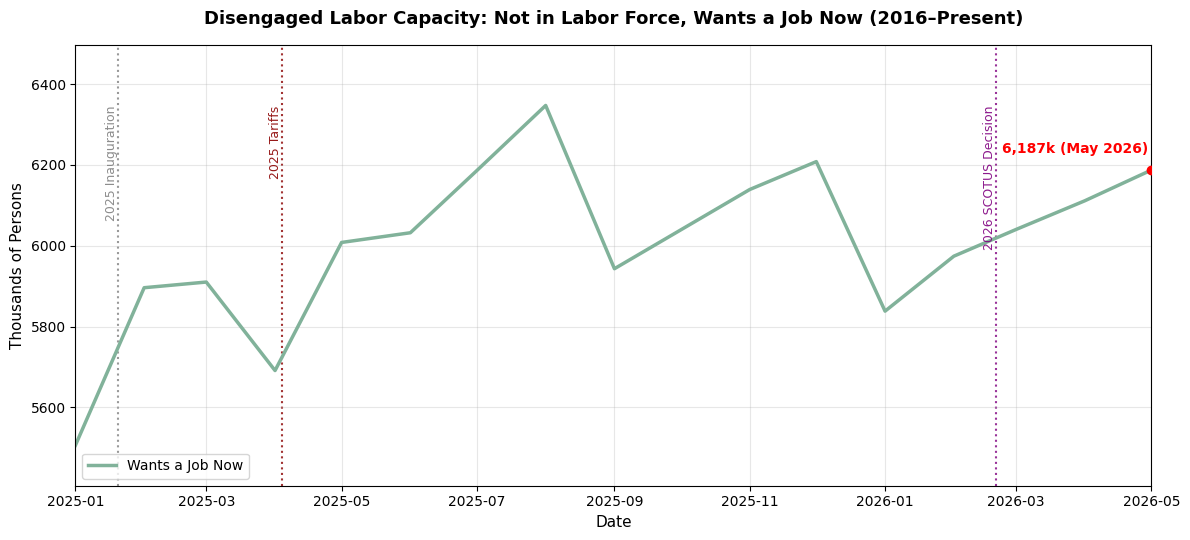

In [ ]:
df_latent = df_kpi[['Not in Labor Force, Wants a Job']].dropna()

plt.figure(figsize=(12, 5.5))
plt.plot(df_latent.index, df_latent['Not in Labor Force, Wants a Job'], color="#14b447", linewidth=2.5, label='Wants a Job Now')

evt_20jan2025 = datetime(2025, 1, 20)
evt_4apr2025 = datetime(2025, 4, 4)
evt_20feb2026 = datetime(2026, 2, 20)

y_max = df_latent['Not in Labor Force, Wants a Job'].max()
y_min = df_latent['Not in Labor Force, Wants a Job'].min()

for evt, label, col in [(evt_20jan2025, "2025 Inauguration", "gray"),
                        (evt_4apr2025, "2025 Tariffs", "darkred"),
                        (evt_20feb2026, "2026 SCOTUS Decision", "purple")]:
    plt.axvline(evt, color = col, linestyle = ':', alpha = 0.8, zorder = 1)
    plt.text(evt, y_max, label, rotation = 90, va = 'top', ha = 'right', fontsize = 9, color = col, alpha = 0.9)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlim(start, df_latent.index.max())
plt.ylim(y_min - 100, y_max + 150)

plt.title("Disengaged Labor Capacity: Not in Labor Force, Wants a Job (2025–Present)", fontsize = 13, pad = 15, weight = 'bold')
plt.ylabel("Thousands of Persons", fontsize = 11)
plt.xlabel("Date", fontsize = 11)
plt.grid(alpha = 0.3)
plt.legend(loc = 'lower left')

latest_date = df_latent.index[-1]
latest_val = df_latent['Not in Labor Force, Wants a Job'].iloc[-1]

plt.scatter(latest_date, latest_val, color = 'red', zorder = 5)
plt.annotate(f"{int(latest_val):,}k ({latest_date.strftime('%b %Y')})", 
             (latest_date, latest_val), textcoords = "offset points", 
             xytext= (-55, 12), ha = 'center', weight = 'bold', color = 'red')

plt.tight_layout()
plt.show()

## Metric 5: Cross-Sectional Demographicc Disparity
### Segmented Unemployment Rates Across Racial, Gender, and Generational

/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_41557/3018898094.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = 'Demographic', y = 'Unemployment Rate', data = df_snapshot, palette = colors)


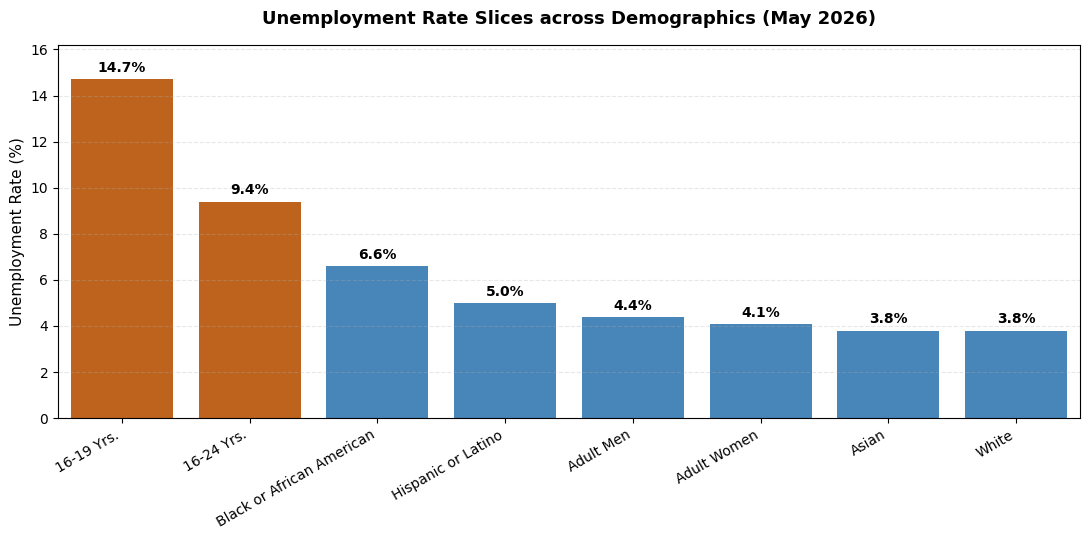

In [17]:
demo_series = {
    'LNS14000003': 'White',
    'LNS14000006': 'Black or African American',
    'LNS14032183': 'Asian',
    'LNS14000009': 'Hispanic or Latino',
    'LNS14000001': 'Adult Men',
    'LNS14000002': 'Adult Women',
    'LNS14024887': '16-24 Yrs.',
    'LNS14000012': '16-19 Yrs.'
}

df_demo = web.DataReader(list(demo_series.keys()), 'fred', datetime(2025, 1, 1), datetime.now())
df_demo.rename(columns = demo_series, inplace = True)

latest_row = df_demo.dropna().tail(1)
target_month_str = latest_row.index[0].strftime('%B %Y')

df_snapshot = pd.DataFrame({
    'Demographic': latest_row.columns,
    'Unemployment Rate': latest_row.values[0]
}).sort_values(by='Unemployment Rate', ascending=False)

plt.figure(figsize=(11, 5.5))

colors = ["#d95f028d" if 'Yrs' in cat else "#3587cb" for cat in df_snapshot['Demographic']]
ax = sns.barplot(x = 'Demographic', y = 'Unemployment Rate', data = df_snapshot, palette = colors)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1f}%", 
                (p.get_x() + p.get_width() / 2., height), 
                ha = 'center', va = 'center', xytext = (0, 8), 
                textcoords = 'offset points', fontsize = 10, weight = 'bold')

plt.title(f"Unemployment Rate Slices across Demographics ({target_month_str})", fontsize = 13, pad = 15, weight = 'bold')
plt.ylabel("Unemployment Rate (%)", fontsize = 11)
plt.xlabel("")
plt.xticks(rotation = 30, ha = 'right')

plt.ylim(0, df_snapshot['Unemployment Rate'].max() + 1.5)
plt.grid(axis = 'y', alpha = 0.3, linestyle = '--')

plt.tight_layout()
plt.show()

# Conlusions and Observations

I've personally spent weeks on end developing products, reviewing systems, observing changes in the markets, and reading into investment platforms; the reason for doing so is to remain educated and informed about the ongoing developments in the outer world. The job market is no different as there are no lifetime appointments outside of federal courts and some persons within academia.

As a person who neither holds bar certification, nor a master's in education, I do not expect to remain employed in any role regardless of the needs of the employer and how well I meet them on a contractual basis. However, as an African-born American, the needs of the individual are a significant component of the needs for the group, otherwise the group has no needs.

Today is Friday, June 5, 2026, and the monthly BLS Jobs report returned positive results, netting 172,000 jobs added in the month of May, including revisions in the months of March and April by 29,000 and 64,000 jobs, to 214,000 and 179,000 respectively. Unemployment remained unchanged from March 2026, holding at 4.3% in March, April, and May. Ultimately, very attractive figures and a good sign for America in the aftermath of the Supreme Court's decision regarding Donald Trump's tariff policies, and the start of the Iran War.

#### *But a closer look at the important metrics tells a much different story. A broader look at the country today tells an even greater one.*

The arithmetic regarding labor force participation, unemployment rates, jobs growth, and job availability doesn't work out. 

The United States adding a net **565,000** jobs in 3 months is impressive, and would otherwise have a static effect on unemployment to the tune of an effective unemployment rate around **4%**. Instead the needle did not move.

Since February 2026, labor force participation has been dropping at an average of **0.067% per month** or about **184,450** American Jobs per month. Over the course of 4 months, the net growth in jobs i the United States between the reported jobs added and labor force participation, is a net loss of **~172,000 jobs.**

That's the same number of jobs reported to have been ***ADDED*** in May 2026. Since February 2026, ***213,200 MORE*** people fell into the category of marginalized workforce, wanting a job albeit out of the labor force. **Roughly 1,000 job LESS than the revised jobs added for March 2026.** Finally, **101,000 MORE individuals reported Unemployment longer than 27 weeks** since February 2026.

#### *There is quite a lot to be had here, and I wouldn't buy any of it.*

**Data can be manipulated to fascilitate lies.** 

**A net growth of negative 214,000 jobs in the last four months would make certain people in power angry.**

**So angry in fact, a third person could occupy the leadership behind these figures, over the course of just 18 months.**

Unemploymentt and jobs growth numbers are just that, numbers. But how the figures are transformed affect the paint required for the portrait. 

I believe the massive jobs numbers are manipulated, improper, and invalid. I have hopes that these figures reflect promoted hires, lateral hires, RTO policies for entrenched workers, persons retturning from retirement, and hiring reflecting new graduates. 

But I know better and I'm old enough to remember the state of the nation under previous administrations. 

Everyone is welcomed to believe what they choose and accept the facts as they become available. My skeptism regarding rescent reports is grounded on the basis that real GDP growtth recent returned at 1.6% year-over-year, US Real DPI (Disposble Income) delcined **0.8%** in three months, and personal savings in the same timeframe has declined **2.6%.**

**Thanks for stopping to smell the flowers. I'm sure they smell better than these reports.**